In [5]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

Pada tahap ini dilakukan impor berbagai library yang diperlukan untuk proses pengolahan citra, ekstraksi fitur, klasifikasi, dan evaluasi model. Library os digunakan untuk mengakses serta mengelola file dan folder dataset, sedangkan OpenCV (cv2)digunakan untuk membaca, mengubah, dan memproses citra digital. NumPy (np) berfungsi untuk mengolah data dalam bentuk array dan melakukan perhitungan numerik secara efisien, sementara Matplotlib (plt) digunakan untuk menampilkan citra maupun grafik hasil pengolahan. Pandas (pd) digunakan untuk menyimpan dan mengelola data hasil ekstraksi fitur dalam bentuk tabel (DataFrame). Pada tahap pembagian data, train_test_split digunakan untuk memisahkan dataset menjadi data latih dan data uji, sedangkan cross_val_predict dapat digunakan untuk melakukan validasi silang (cross validation) agar evaluasi model lebih akurat. Untuk ekstraksi fitur tekstur digunakan metode Gray Level Co-occurrence Matrix (GLCM) melalui fungsi graycomatrix, kemudian karakteristik tekstur seperti contrast, homogeneity, correlation, energy, dan ASM dihitung menggunakan graycoprops, sedangkan fungsi entropy dari SciPy digunakan untuk menghitung tingkat kerandoman atau kompleksitas tekstur citra. Pada tahap klasifikasi digunakan tiga algoritma machine learning, yaitu Support Vector Machine (SVC), Random Forest (RandomForestClassifier), dan K-Nearest Neighbor (KNeighborsClassifier)** untuk membandingkan performa klasifikasi. Selanjutnya, hasil klasifikasi dievaluasi menggunakan berbagai metrik dari Scikit-Learn seperti accuracy_score, precision_score, recall_score, dan f1_score, sedangkan confusion_matrix, ConfusionMatrixDisplay, dan classification_report digunakan untuk menampilkan hasil evaluasi secara rinci. Selain itu, Seaborn (sns)bdigunakan untuk membantu visualisasi data atau menampilkan confusion matrix dalam bentuk grafik yang lebih informatif dan mudah dibaca.


In [6]:
data = []
labels = []
file_name = []

IMG_SIZE = (256, 328)

for sub_folder in os.listdir("Assets"):
    sub_folder_files = os.listdir(os.path.join("Assets", sub_folder))
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join("Assets", sub_folder, filename)
        img = cv.imread(img_path)

        if img is None:
            continue

        img = cv.resize(img, IMG_SIZE)
        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
        img = img.astype(np.uint8)

        data.append(img)
        labels.append(sub_folder)
        file_name.append(filename)

data = np.array(data)
labels = np.array(labels)
print(f"Total data: {len(data)}, Shape: {data.shape}")
print(f"Labels: {np.unique(labels, return_counts=True)}")

Total data: 298, Shape: (298, 328, 256)
Labels: (array(['Coal', 'Limestone', 'Sandstone'], dtype='<U9'), array([ 99,  97, 102]))


Kode ini digunakan untuk membaca seluruh citra yang terdapat pada folder dataset dan mempersiapkannya untuk proses pengolahan selanjutnya. Program terlebih dahulu membuat tiga list, yaitu data untuk menyimpan citra, labels untuk menyimpan kelas citra berdasarkan nama folder, dan file_name untuk menyimpan nama file gambar. Selanjutnya program melakukan perulangan pada setiap subfolder di dalam folder Assets. Setiap subfolder dianggap sebagai sebuah kelas data. Setiap gambar dibaca menggunakan cv.imread(), kemudian dilakukan pengecekan untuk memastikan gambar berhasil dimuat. Gambar yang berhasil dibaca kemudian diubah ukurannya menjadi 256 × 328 piksel agar seluruh data memiliki dimensi yang seragam. Setelah itu citra dikonversi menjadi grayscale sehingga hanya memiliki satu kanal intensitas dan tipe datanya diubah menjadi uint8. Citra hasil preprocessing disimpan ke dalam list data, sedangkan nama subfolder disimpan sebagai label kelas pada list labels dan nama file disimpan pada list file_name. Setelah seluruh gambar selesai diproses, data dan labels diubah menjadi array NumPy agar lebih mudah digunakan pada tahap ekstraksi fitur dan klasifikasi. Terakhir, program menampilkan jumlah total data yang berhasil dimuat beserta distribusi jumlah citra pada setiap kelas.


# Data Preparation 

### Define Preprocessing Function

In [7]:
TARGET_SIZE = (256, 328)
def resize_grayscale(image, target_size=TARGET_SIZE):
    resized = cv.resize(image, target_size)

    if len(resized.shape) == 3:
        gray = cv.cvtColor(resized, cv.COLOR_BGR2GRAY)
    else:
        gray = resized

    return gray.astype(np.uint8)

def thresholding(img, batas):
    baris, kolom = img.shape
    canvas = np.zeros_like(img, dtype=np.uint8)

    for i in range(baris):
        for j in range(kolom):
            if(img[i,j] > batas):
                canvas[i,j] = 255
            elif(img[i,j] <= batas):
                canvas[i,j] = 0

    return canvas

kernel = np.array([[0, 0, 1, 0, 0],
                   [0, 0, 1, 0, 0],
                   [1, 1, 1, 1, 1],
                   [0, 0, 1, 0, 0],
                   [0, 0, 1, 0, 0]], dtype=np.uint8)

def dilasi(img, kernel):
    img = img.copy()
    pad_h, pad_w = kernel.shape[0] // 2, kernel.shape[1] // 2
    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')
    output = np.zeros_like(img)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i:i+kernel.shape[0], j:j+kernel.shape[1]]
            if np.any(region[kernel == 1] == 255):
                output[i, j] = 255
    return output


def erosi(img, kernel):
    img = img.copy()
    pad_h, pad_w = kernel.shape[0] // 2, kernel.shape[1] // 2
    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')
    output = np.zeros_like(img)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i:i+kernel.shape[0], j:j+kernel.shape[1]]
            if np.all(region[kernel == 1] == 255):
                output[i, j] = 255
    return output

def opening(img, kernel):
    return dilasi(erosi(img, kernel), kernel)
def closing(img, kernel):
    return erosi(dilasi(img, kernel), kernel)

In [8]:
def prepro(image):
    # Resize + Grayscale
    img = resize_grayscale(image)
    # Thresholding
    thresh = thresholding(img, 127)
    # Opening
    opened = opening(thresh, kernel)
    # Closing
    closed = closing(opened, kernel)
    return closed

Kode ini berisi beberapa fungsi yang digunakan pada tahap preprocessing citra. Fungsi resize_grayscale() digunakan untuk mengubah ukuran gambar menjadi 256 × 328 piksel agar seluruh citra memiliki dimensi yang seragam. Setelah itu dilakukan pengecekan jumlah kanal citra. Jika citra masih berwarna, citra akan dikonversi menjadi grayscale sehingga setiap piksel hanya memiliki satu nilai intensitas. Hasil akhirnya dikembalikan dalam format uint8.

Fungsi thresholding() digunakan untuk mengubah citra grayscale menjadi citra biner berdasarkan nilai ambang tertentu. Setiap piksel yang memiliki nilai lebih besar dari nilai ambang akan diubah menjadi 255 (putih), sedangkan piksel dengan nilai lebih kecil atau sama dengan ambang akan diubah menjadi 0 (hitam). Proses ini bertujuan untuk memisahkan objek dari latar belakang sehingga bentuk objek menjadi lebih jelas.

Kernel yang digunakan pada proses morfologi berbentuk tanda tambah berukuran 5 × 5. Kernel ini digunakan sebagai elemen struktur pada operasi dilasi dan erosi. Fungsi dilasi() bertujuan memperluas area objek putih dengan memeriksa piksel-piksel tetangga sesuai bentuk kernel. Jika terdapat minimal satu piksel bernilai 255 pada area kernel, maka piksel pusat akan diubah menjadi 255. Sebaliknya, fungsi erosi() digunakan untuk mengurangi area objek putih dengan memeriksa seluruh piksel yang berada pada posisi kernel. Piksel pusat hanya akan bernilai 255 apabila seluruh piksel yang diperiksa juga bernilai 255.

Selanjutnya, fungsi opening() merupakan kombinasi operasi erosi yang diikuti dilasi. Operasi ini digunakan untuk menghilangkan noise kecil yang terdapat pada citra tanpa mengubah bentuk objek utama secara signifikan. Sementara itu, fungsi closing() merupakan kombinasi dilasi yang diikuti erosi dan digunakan untuk menutup lubang-lubang kecil atau celah pada objek sehingga bentuk objek menjadi lebih utuh. Hasil dari rangkaian proses ini adalah citra biner yang lebih bersih dan siap digunakan pada tahap ekstraksi fitur.


## Percobaan 4 (resize + grayscale + thresholding + opening + closing)

Kode ini digunakan untuk menerapkan proses preprocessing pada seluruh citra yang terdapat dalam dataset serta menampilkan hasilnya berdasarkan kelas masing-masing. Fungsi percobaan4() memanggil fungsi prepro() yang berisi rangkaian tahapan preprocessing, kemudian mengembalikan citra hasil pengolahan. Selanjutnya, seluruh citra pada variabel data diproses menggunakan list comprehension dan disimpan ke dalam variabel dataPreprocessed.

Program kemudian mengambil seluruh label unik yang terdapat pada dataset dan melakukan perulangan untuk setiap kelas. Pada setiap kelas, program mencari indeks seluruh citra yang memiliki label yang sama. Setelah itu dibuat sebuah grid berukuran 4 × 6 menggunakan Matplotlib sehingga dapat menampilkan maksimal 24 citra dalam satu tampilan. Setiap citra hasil preprocessing ditampilkan dalam format grayscale dan sumbu koordinat disembunyikan agar visualisasi lebih mudah diamati.

Judul pada setiap gambar kelompok ditampilkan menggunakan nama kelas yang bersangkutan. Dengan visualisasi ini, hasil preprocessing dapat diamati secara langsung untuk setiap kelas sehingga memudahkan proses evaluasi terhadap kualitas citra sebelum dilakukan ekstraksi fitur dan klasifikasi.


In [ ]:
def percobaan4(img):
    hasil = prepro(img)
    return hasil

dataPreprocessed = [percobaan4(img) for img in data]

unique_labels = sorted(set(labels))

for label in unique_labels:
    idxs = [j for j, l in enumerate(labels) if l == label]

    fig, axs = plt.subplots(4, 6, figsize=(12, 8))
    fig.suptitle(f'{label}', fontsize=16)

    for k in range(min(24, len(idxs))):
        row = k // 6
        col = k % 6
        ax = axs[row][col]

        ax.imshow(dataPreprocessed[idxs[k]], cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

In [ ]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

Kode ini digunakan untuk membentuk Gray Level Co-occurrence Matrix (GLCM) dari sebuah citra. Fungsi glcm() menerima dua parameter, yaitu image yang merupakan citra masukan dan derajat yang menunjukkan arah hubungan antar piksel yang akan dianalisis. Program terlebih dahulu mengubah nilai sudut yang diberikan, yaitu 0°, 45°, 90°, atau 135°, ke dalam satuan radian karena fungsi graycomatrix() menggunakan radian sebagai parameter sudut. Jika nilai sudut yang dimasukkan tidak sesuai dengan pilihan yang tersedia, program akan menampilkan pesan kesalahan.

Setelah sudut ditentukan, fungsi graycomatrix() digunakan untuk membentuk matriks GLCM dengan jarak antar piksel sebesar 1 piksel. Parameter symmetric=True digunakan agar hubungan antar pasangan piksel dihitung secara simetris, sedangkan normed=True digunakan untuk melakukan normalisasi sehingga nilai pada matriks menjadi probabilitas. Hasil yang dikembalikan oleh fungsi ini adalah matriks GLCM yang merepresentasikan distribusi hubungan antar tingkat keabuan pada citra dan akan digunakan pada tahap ekstraksi fitur tekstur.

In [ ]:

def correlation(matriks):
	return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

Kode ini digunakan untuk menghitung berbagai fitur tekstur dari matriks Gray Level Co-occurrence Matrix (GLCM). Setiap fungsi menerima parameter berupa matriks GLCM yang telah dibentuk sebelumnya, kemudian menghitung karakteristik tekstur tertentu menggunakan fungsi graycoprops() dari pustaka scikit-image. Fitur correlation digunakan untuk mengukur hubungan atau ketergantungan antar nilai piksel yang berdekatan. Fitur dissimilarity mengukur tingkat perbedaan nilai keabuan antar pasangan piksel, sedangkan homogeneity mengukur tingkat keseragaman tekstur pada citra. Fitur contrast digunakan untuk melihat tingkat kontras atau variasi intensitas antar piksel dalam citra.

Selain itu, fitur ASM (Angular Second Moment) digunakan untuk mengukur tingkat keseragaman distribusi nilai pada matriks GLCM, sedangkan energy merupakan akar kuadrat dari ASM yang menunjukkan tingkat keteraturan tekstur. Fungsi entropyGlcm() digunakan untuk menghitung nilai entropi dari matriks GLCM dengan memanfaatkan fungsi entropy() dari SciPy. Nilai entropi menunjukkan tingkat kerandoman atau kompleksitas tekstur, di mana semakin tinggi nilainya maka tekstur citra cenderung semakin kompleks. Seluruh fitur yang diperoleh nantinya digunakan sebagai representasi numerik dari tekstur citra untuk proses klasifikasi.


In [ ]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

for i in range(len(data)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

for i in range(len(data)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

for i in range(len(data)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

for i in range(len(data)):
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

for i in range(len(data)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

for i in range(len(data)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)


Kode ini digunakan untuk melakukan ekstraksi fitur tekstur GLCM pada seluruh citra hasil preprocessing. Pertama, program membuat empat list kosong untuk menyimpan matriks GLCM berdasarkan arah sudut 0°, 45°, 90°, dan 135°. Setiap citra pada dataPreprocessed kemudian diproses menggunakan fungsi glcm() pada keempat sudut tersebut, lalu hasil matriksnya disimpan ke dalam list sesuai arah sudutnya.

Setelah matriks GLCM terbentuk, program membuat beberapa list kosong untuk menyimpan nilai fitur tekstur dari masing-masing sudut. Fitur yang dihitung meliputi correlation, contrast, dissimilarity, homogeneity, entropy, ASM, dan energy. Setiap fitur dihitung dari matriks GLCM pada sudut 0°, 45°, 90°, dan 135°, sehingga satu citra memiliki beberapa nilai fitur dari berbagai arah tekstur.

Proses ini bertujuan untuk mengubah citra menjadi data numerik yang dapat dibaca oleh algoritma klasifikasi. Nilai-nilai fitur tersebut nantinya digunakan sebagai ciri pembeda antar kelas citra, sehingga model seperti KNN, SVM, atau Random Forest dapat mempelajari pola tekstur dari setiap kelas.


## Ekstraksi ke csv
Kode ini digunakan untuk menggabungkan seluruh hasil ekstraksi fitur GLCM ke dalam sebuah tabel yang terstruktur. Program membuat sebuah dictionary bernama dataTable yang berisi nama file, label kelas, serta seluruh fitur tekstur yang telah dihitung sebelumnya, yaitu contrast, homogeneity, dissimilarity, entropy, ASM, energy, dan correlation pada sudut 0°, 45°, 90°, dan 135°. Setiap kolom pada dictionary merepresentasikan satu jenis fitur, sedangkan setiap baris merepresentasikan satu citra.
Selanjutnya dictionary tersebut dikonversi menjadi DataFrame menggunakan Pandas dan disimpan pada variabel df. DataFrame kemudian diekspor ke dalam file CSV dengan nama hasil_ekstraksi_Percobaan4.csv menggunakan fungsi to_csv(). Penyimpanan ke dalam format CSV bertujuan agar hasil ekstraksi fitur dapat digunakan kembali tanpa perlu melakukan proses ekstraksi dari awal. Setelah file CSV berhasil dibuat, data dibaca kembali menggunakan pd.read_csv() dan disimpan pada variabel hasilEkstrak. Langkah ini dilakukan untuk memastikan data berhasil tersimpan dengan baik serta memudahkan proses analisis dan klasifikasi pada tahap berikutnya.

In [ ]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('./hasil_ekstraksi/hasil_ekstraksi_Percobaan4.csv', index=False)

hasilEkstrak = pd.read_csv('./hasil_ekstraksi/hasil_ekstraksi_Percobaan4.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,0.jpg,Coal,1234.573171,1946.422018,1079.710794,1885.596330,0.981014,0.970067,0.983396,0.971002,...,0.484097,0.472165,0.694101,0.686501,0.695771,0.687142,0.961997,0.940095,0.966763,0.941967
1,1.jpg,Coal,2655.731707,3414.036697,2390.899154,3649.541284,0.959159,0.947497,0.963232,0.943876,...,0.611673,0.593143,0.779553,0.772251,0.782095,0.770158,0.884342,0.851636,0.895812,0.841401
2,10.jpg,Coal,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3,100.jpg,Coal,384.054878,450.733945,253.227136,463.211009,0.994094,0.993068,0.996106,0.992877,...,0.951165,0.947799,0.974235,0.973647,0.975277,0.973550,0.868732,0.846400,0.913376,0.842148
4,11.jpg,Coal,3451.829268,4501.100917,3268.649656,4786.513761,0.946916,0.930780,0.949733,0.926391,...,0.522715,0.501348,0.721102,0.710711,0.722990,0.708059,0.876474,0.839193,0.882975,0.828996
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
293,95.jpg,Sandstone,2035.335366,2858.807339,2010.281680,2863.486239,0.968700,0.956036,0.969085,0.955964,...,0.612234,0.599122,0.782086,0.774072,0.782454,0.774030,0.912572,0.877461,0.913597,0.877260
294,96.jpg,Sandstone,1847.195122,2030.642202,1311.188360,2546.880734,0.971593,0.968772,0.979836,0.960833,...,0.623624,0.604774,0.784581,0.782403,0.789699,0.777672,0.920390,0.912670,0.943457,0.890468
295,97.jpg,Sandstone,1408.719512,1664.128440,1154.280748,2085.229358,0.978336,0.974408,0.982249,0.967932,...,0.596245,0.581665,0.769592,0.766660,0.772169,0.762670,0.943952,0.933921,0.954050,0.917200
296,98.jpg,Sandstone,769.664634,1168.165138,635.398151,1168.165138,0.988164,0.982035,0.990229,0.982035,...,0.491732,0.483993,0.699829,0.695696,0.701236,0.695696,0.976258,0.963952,0.980402,0.963952


## Feature Selection
Seleksi fitur dilakukan menggunakan metode korelasi antar fitur dengan threshold 0.95. Fitur yang memiliki nilai korelasi absolut lebih dari atau sama dengan threshold akan dihapus karena dianggap membawa informasi yang sama dengan fitur lain.
Dari 28 fitur hasil ekstraksi GLCM, setelah seleksi diperoleh 3 fitur yaitu Contrast0, Entropy0, dan Correlation0. Fitur lainnya dihapus karena terlalu mirip satu sama lain, misalnya Homogeneity0 yang korelasinya -1.00 dengan Contrast0, dan ASM0 yang korelasinya -0.99 dengan Entropy0. Ketiga fitur yang tersisa memiliki korelasi yang cukup rendah satu sama lain sehingga masing-masing membawa informasi yang berbeda dan tidak redundan, sehingga layak digunakan sebagai input untuk proses klasifikasi.

<Axes: >

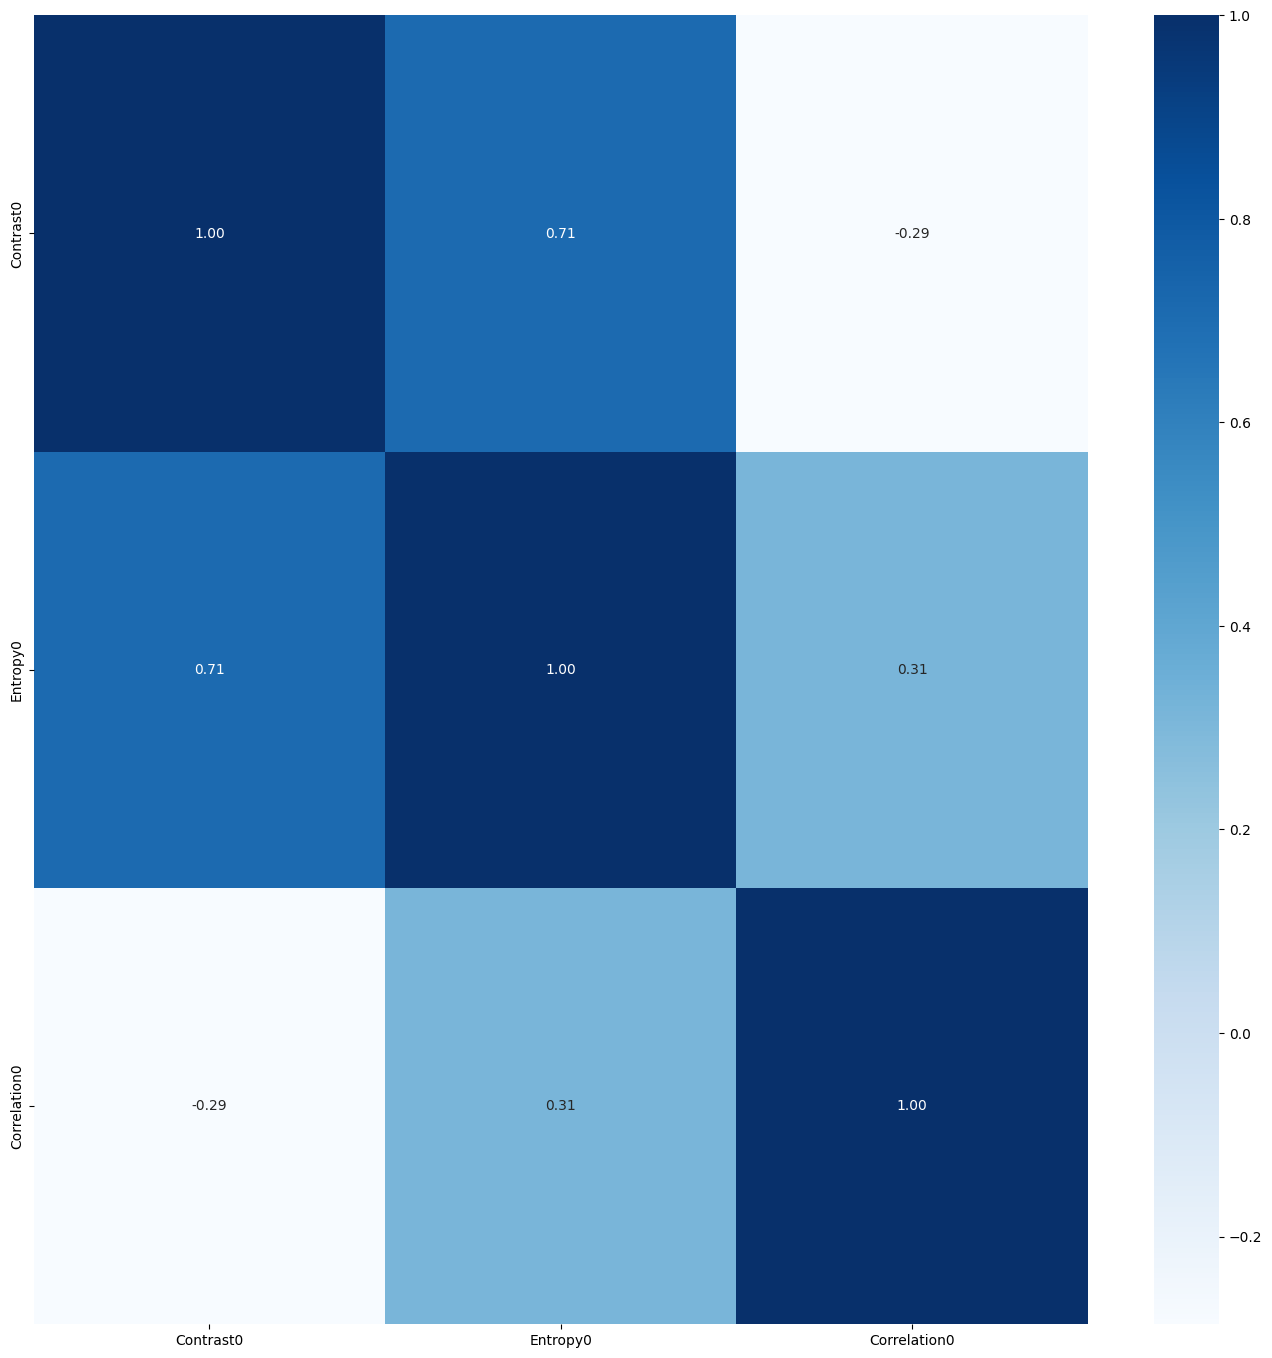

In [ ]:
correlation = hasilEkstrak.drop(columns=['Label','Filename']).corr()

# Menyaring fitur yang memiliki korelasi absolut lebih dari 0.95 dengan label
threshold = 0.95 # atur threshold ini untuk menentukan seberapa besar korelasi yang ingin disaring
selectionFeature = []
columns = np.full((correlation.shape[0],), True, dtype=bool)
for i in range(correlation.shape[0]):
	for j in range(i+1, correlation.shape[0]):
		if abs(correlation.iloc[i,j]) >= threshold:
			if columns[j]:
				columns[j] = False
select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
x_new
y = hasilEkstrak['Label']
plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(238, 3)
(60, 3)


## Splitting Data
Data dibagi menjadi dua bagian yaitu data training dan data testing menggunakan perbandingan 80:20, artinya 80% data digunakan untuk melatih model dan 20% sisanya digunakan untuk menguji performa model. Pembagian ini dipilih karena jumlah data yang tersedia tidak terlalu banyak, sehingga porsi training yang lebih besar dapat membantu model belajar lebih optimal. Dari total 298 data, diperoleh 238 data training dan 60 data testing dengan masing-masing memiliki 3 fitur hasil seleksi.

In [ ]:
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

## Normalisasi Fitur
Normalisasi dilakukan menggunakan metode Z-score (Standardization), yaitu dengan mengurangi nilai rata-rata lalu dibagi dengan standar deviasi. Proses normalisasi menggunakan parameter mean dan standar deviasi dari data training, dan parameter yang sama diterapkan juga ke data testing. Hal ini dilakukan agar tidak terjadi data leakage, yaitu kondisi di mana informasi dari data testing ikut mempengaruhi proses training. Setelah normalisasi, setiap fitur akan memiliki distribusi dengan rata-rata mendekati 0 dan standar deviasi mendekati 1, sehingga ketiga fitur berada dalam skala yang sama dan tidak ada fitur yang mendominasi proses klasifikasi.

# MODELING

In [ ]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

## Define Model
Kode ini digunakan untuk menyiapkan proses evaluasi dan klasifikasi data. Fungsi generateClassificationReport() dibuat untuk menampilkan hasil evaluasi model klasifikasi. Fungsi ini menerima data label sebenarnya (y_true) dan hasil prediksi model (y_pred), kemudian menampilkan classification report yang berisi nilai precision, recall, f1-score, dan support untuk setiap kelas. Selain itu, fungsi juga menampilkan confusion matrix untuk melihat jumlah prediksi yang benar maupun salah pada masing-masing kelas, serta nilai accuracy untuk mengetahui tingkat ketepatan model secara keseluruhan. Selanjutnya didefinisikan tiga algoritma klasifikasi yang akan digunakan dalam penelitian. RandomForestClassifier digunakan untuk membangun model Random Forest dengan lima pohon keputusan dan nilai random_state sebesar 42 agar hasil eksperimen dapat direproduksi. SVC digunakan untuk membangun model Support Vector Machine dengan kernel Radial Basis Function (RBF) yang mampu menangani data yang tidak terpisahkan secara linear. Selain itu, KNeighborsClassifier digunakan untuk membangun model K-Nearest Neighbor dengan nilai k sebesar 5, sehingga proses klasifikasi dilakukan berdasarkan lima tetangga terdekat dari setiap data uji. Ketiga algoritma ini nantinya digunakan untuk membandingkan performa klasifikasi berdasarkan fitur tekstur yang telah diekstraksi menggunakan metode GLCM.


## Hasil Modeling Random Forest
* ### Training Set
Pada data training, model Random Forest menghasilkan akurasi sebesar 92.4%. Performa per kelas juga cukup baik, di mana Coal mencapai f1-score 0.94, Limestone 0.91, dan Sandstone 0.92. Dari confusion matrix training, hampir seluruh data berhasil diklasifikasikan dengan benar, dengan kesalahan yang sangat sedikit.
* ### Testing Set
Namun ketika diuji pada data testing, akurasi turun drastis menjadi hanya 40%. Performa per kelas juga sangat rendah, di mana Coal hanya mencapai f1-score 0.44, Limestone 0.41, dan Sandstone 0.32. Dari confusion matrix testing terlihat model kesulitan membedakan ketiga kelas, Coal hanya benar diprediksi 10 dari 23 data, Limestone 9 dari 22 data, dan Sandstone hanya 5 dari 15 data.
* ### Analisis
Perbedaan yang sangat jauh antara akurasi training (92.4%) dan testing (40%) menunjukkan bahwa model mengalami overfitting. Model terlalu hafal pola pada data training tetapi gagal mengenali data baru yang belum pernah dilihat sebelumnya. Hal ini kemungkinan besar disebabkan oleh preprocessing Percobaan 4 yang menggunakan thresholding dengan nilai tetap 127 sehingga mengubah gambar menjadi citra biner. Proses ini menghilangkan banyak informasi tekstur halus yang sebenarnya sangat dibutuhkan oleh GLCM untuk membedakan antar jenis batuan. Akibatnya fitur yang dihasilkan kurang representatif dan model tidak mampu melakukan generalisasi dengan baik pada data baru.

In [ ]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

        Coal       0.91      0.97      0.94        76
   Limestone       0.92      0.91      0.91        75
   Sandstone       0.94      0.90      0.92        87

    accuracy                           0.92       238
   macro avg       0.92      0.93      0.92       238
weighted avg       0.92      0.92      0.92       238

[[74  0  2]
 [ 4 68  3]
 [ 3  6 78]]
Accuracy: 0.9243697478991597

------Testing Set------
              precision    recall  f1-score   support

        Coal       0.45      0.43      0.44        23
   Limestone       0.41      0.41      0.41        22
   Sandstone       0.31      0.33      0.32        15

    accuracy                           0.40        60
   macro avg       0.39      0.39      0.39        60
weighted avg       0.40      0.40      0.40        60

[[10  7  6]
 [ 8  9  5]
 [ 4  6  5]]
Accuracy: 0.4


## Hasil Modeling SVM
* ### Training Set
Pada data training, model SVM menghasilkan akurasi sebesar 57.6%. Performa per kelas juga tergolong rendah, di mana Coal mencapai f1-score 0.63, Limestone 0.60, dan Sandstone hanya 0.52. Dari confusion matrix training terlihat banyak data yang salah diklasifikasikan, terutama Sandstone yang sering salah diprediksi sebagai Coal maupun Limestone.
* ### Testing Set
Pada data testing, akurasi sedikit meningkat menjadi 45%. Coal menjadi kelas yang paling baik dengan f1-score 0.67, diikuti Limestone dengan 0.43, sedangkan Sandstone sangat buruk dengan f1-score hanya 0.17. Dari confusion matrix testing, Coal cukup baik diprediksi dengan 16 dari 23 data benar, namun Sandstone hanya benar 3 dari 15 data dan banyak salah diklasifikasikan sebagai Coal atau Limestone.
* ### Analisis
Berbeda dengan Random Forest, gap antara akurasi training dan testing pada SVM tidak terlalu jauh, yaitu 57.6% di training dan 45% di testing. Hal ini menunjukkan model tidak terlalu overfitting, namun akurasi keduanya yang sama-sama rendah mengindikasikan model mengalami underfitting, artinya model memang kesulitan mempelajari pola dari data ini. Kondisi ini kemungkinan disebabkan karena dengan hanya 3 fitur hasil seleksi, informasi yang tersedia tidak cukup bagi SVM untuk menemukan hyperplane yang optimal dalam memisahkan ketiga kelas batuan. Preprocessing thresholding yang menghasilkan citra biner juga membuat variasi nilai fitur GLCM menjadi sangat terbatas sehingga batas antar kelas menjadi tidak jelas.

In [ ]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

        Coal       0.65      0.61      0.63        76
   Limestone       0.61      0.59      0.60        75
   Sandstone       0.49      0.54      0.52        87

    accuracy                           0.58       238
   macro avg       0.58      0.58      0.58       238
weighted avg       0.58      0.58      0.58       238

[[46  6 24]
 [ 7 44 24]
 [18 22 47]]
Accuracy: 0.5756302521008403

------Testing Set------
              precision    recall  f1-score   support

        Coal       0.64      0.70      0.67        23
   Limestone       0.53      0.36      0.43        22
   Sandstone       0.15      0.20      0.17        15

    accuracy                           0.45        60
   macro avg       0.44      0.42      0.42        60
weighted avg       0.48      0.45      0.46        60

[[16  0  7]
 [ 4  8 10]
 [ 5  7  3]]
Accuracy: 0.45


## Hasil Modeling KNN
* ### Training Set
Pada data training, model KNN menghasilkan akurasi sebesar 68.9%. Performa per kelas menunjukkan Coal mencapai f1-score 0.80, Limestone 0.69, dan Sandstone 0.57. Dari confusion matrix training, Coal dan Limestone cukup baik diklasifikasikan, namun Sandstone sudah mulai menunjukkan banyak kesalahan dengan 16 data salah diprediksi sebagai Coal dan 29 data salah diprediksi sebagai Limestone.
* ### Testing Set
Pada data testing, akurasi turun menjadi 45%. Coal masih menjadi kelas terbaik dengan f1-score 0.57, diikuti Limestone dengan 0.51, sedangkan Sandstone sangat buruk dengan f1-score hanya 0.08. Dari confusion matrix testing, Sandstone hanya benar diprediksi 1 dari 15 data, dan hampir seluruhnya salah diklasifikasikan sebagai Coal atau Limestone.
* ### Analisis
Gap antara akurasi training (68.9%) dan testing (45%) pada KNN menunjukkan adanya overfitting yang cukup signifikan. Hal ini wajar terjadi pada KNN karena algoritma ini bersifat instance-based, artinya model bekerja dengan cara menghitung jarak ke data training terdekat. Ketika data testing memiliki distribusi fitur yang berbeda dengan training, performa model langsung menurun. Sandstone secara konsisten menjadi kelas yang paling sulit dikenali oleh ketiga model, yang mengindikasikan bahwa fitur GLCM yang dihasilkan dari preprocessing Percobaan 4 tidak mampu menangkap karakteristik tekstur Sandstone dengan baik. Secara keseluruhan, ketiga model menghasilkan akurasi testing di kisaran 40-45%, yang menunjukkan bahwa permasalahan utama terletak pada kualitas fitur yang dihasilkan dari preprocessing, bukan pada pemilihan algoritma klasifikasi.

In [ ]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

        Coal       0.75      0.84      0.80        76
   Limestone       0.63      0.77      0.69        75
   Sandstone       0.69      0.48      0.57        87

    accuracy                           0.69       238
   macro avg       0.69      0.70      0.69       238
weighted avg       0.69      0.69      0.68       238

[[64  5  7]
 [ 5 58 12]
 [16 29 42]]
Accuracy: 0.6890756302521008

------Testing Set------
              precision    recall  f1-score   support

        Coal       0.54      0.61      0.57        23
   Limestone       0.48      0.55      0.51        22
   Sandstone       0.11      0.07      0.08        15

    accuracy                           0.45        60
   macro avg       0.38      0.41      0.39        60
weighted avg       0.41      0.45      0.43        60

[[14  5  4]
 [ 6 12  4]
 [ 6  8  1]]
Accuracy: 0.45


## Evaluasi Confusion Matrix
Confusion matrix digunakan untuk melihat secara detail bagaimana model melakukan prediksi pada setiap kelas. Sumbu vertikal menunjukkan label sebenarnya (true label) dan sumbu horizontal menunjukkan label yang diprediksi (predicted label), di mana angka 0 merepresentasikan Coal, 1 merepresentasikan Limestone, dan 2 merepresentasikan Sandstone.
Pada Random Forest, diagonal utama menunjukkan nilai yang relatif kecil yaitu 10, 9, dan 5, yang berarti model hanya benar memprediksi sebagian kecil dari masing-masing kelas. Kesalahan prediksi tersebar merata ke seluruh kelas sehingga tidak ada pola kesalahan yang dominan, mencerminkan model yang benar-benar kesulitan membedakan ketiga jenis batuan.
Pada SVM, Coal menjadi kelas yang paling baik diprediksi dengan 16 data benar, namun Limestone memiliki masalah serius di mana 10 dari 22 datanya salah diprediksi sebagai Sandstone. Sandstone juga buruk dengan hanya 3 data benar dari 15. Pola kesalahan SVM lebih terkonsentrasi pada kebingungan antara Limestone dan Sandstone.
Pada KNN, Coal dan Limestone masih cukup terprediksi dengan benar masing-masing 14 dan 12 data, namun Sandstone kembali menjadi kelas paling bermasalah dengan hanya 1 data benar dari 15. Hampir seluruh data Sandstone salah diklasifikasikan sebagai Coal atau Limestone.
Secara keseluruhan, ketiga confusion matrix menunjukkan bahwa Sandstone adalah kelas yang paling sulit dikenali oleh semua model. Hal ini mengindikasikan bahwa fitur GLCM yang dihasilkan dari preprocessing Percobaan 4 tidak mampu menangkap perbedaan tekstur Sandstone secara memadai dibandingkan dua kelas lainnya.

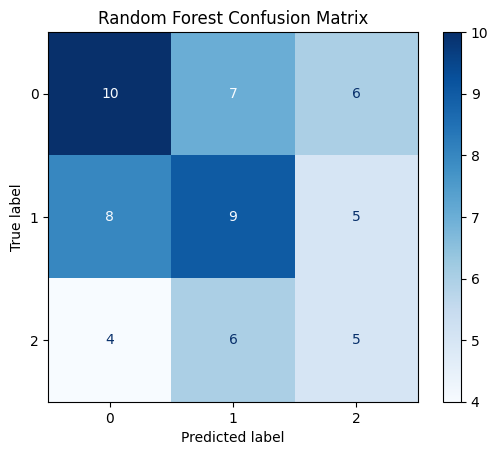

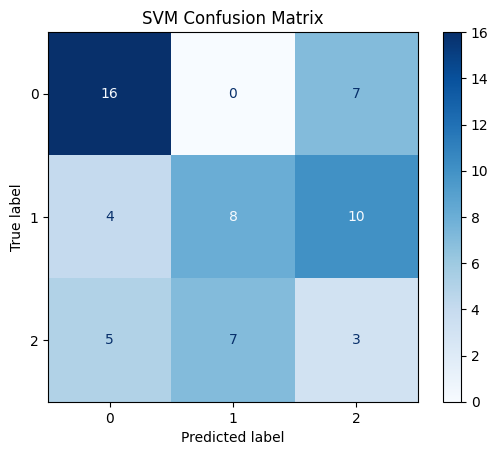

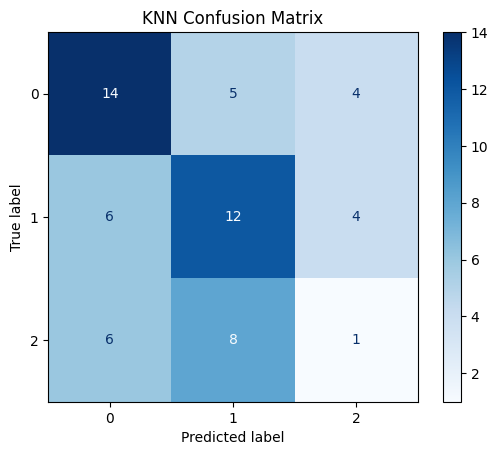

In [ ]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")